### ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

#### 1 - importanto bibliotecas

In [1]:
import pandas as pd
import numpy as np

# importanto dados
df_sales=pd.read_excel(
    'Dados_Sneakers_World3_Python.xlsx',
    sheet_name='Sales'
)


#### 2 - exibição das dimensões originais no Data Frame

In [2]:
print('=' * 50)
print('Etapa 1 - Limpeza e transformação')
print('=' * 50)
print(f'\nDimensões originais: {df_sales.shape[0]} linhas x {df_sales.shape[1]} colunas')

Etapa 1 - Limpeza e transformação

Dimensões originais: 57780 linhas x 12 colunas


#### 3 - verificação dos tipos de dados

In [3]:
print('\n--- Tipos de dados ---')
print(df_sales.dtypes)


--- Tipos de dados ---
OrderNumber                    str
ProductID                    int64
ResellerKey                  int64
EmployeeID                   int64
SalesTerritoryID             int64
Quantity                     int64
UnitPrice                  float64
Sales                      float64
Cost                       float64
OrderDate           datetime64[us]
ShipDate            datetime64[us]
DeliveryDate        datetime64[us]
dtype: object


#### 4 - verificação e remoção de linhas nulas

In [ ]:
print('\n--- Valores nulos por coluna ---')
print(df_sales.isnull().sum())

##### remoção de linhas que contenham ao menos um valor nulo


In [4]:
df_sales_limpo = df_sales.dropna()
print(f'\nDimensões após remoção de nulos: {df_sales.shape[0]} linhas x {df_sales.shape[1]} colunas')


Dimensões após remoção de nulos: 57780 linhas x 12 colunas


#### 5 - verificação e remoção de linhas duplicadas

In [5]:
print(f'\n--- Linhas duplicadas encontradas: {df_sales.duplicated().sum()} ---')


--- Linhas duplicadas encontradas: 0 ---


##### remoção de linhas completamente duplicadas

In [6]:
df_sales=df_sales.drop_duplicates()
print(f'Dimensões após remoção de duplicatas: {df_sales.shape[0]} linhas x {df_sales.shape[1]} colunas')

Dimensões após remoção de duplicatas: 57780 linhas x 12 colunas


#### 6 - Resultado Final da limpeza e transformação

In [7]:
print('\n--- Primeiras linhas por Data Frame limpo ---')
print(df_sales.head())

print('\n Limpeza e transformação concluída com sucesso!')


--- Primeiras linhas por Data Frame limpo ---
  OrderNumber  ProductID  ResellerKey  EmployeeID  SalesTerritoryID  Quantity  \
0      PV5417         17          674         141                 1         2   
1      PV7604         17          674         141                 1         3   
2      PV3568         17          638         141                 1         1   
3      PV1699         17          498         141                 1         1   
4      PV4003         17          498         141                 1        10   

   UnitPrice    Sales       Cost  OrderDate   ShipDate DeliveryDate  
0     11.019   22.038  18.719550 2023-02-18 2023-02-23   2023-03-15  
1     11.019   33.057  23.563031 2023-05-20 2023-05-30   2023-06-17  
2     11.019   11.019   9.582128 2022-11-27 2022-12-03   2022-12-14  
3     11.019   11.019   9.428274 2022-09-16 2022-09-17   2022-10-04  
4     11.019  110.190  98.119612 2022-12-16 2022-12-24   2023-01-03  

 Limpeza e transformação concluída com sucess

---
### 2.a - MÉDIA, MEDIANA E MODA DE "SALES" E "QUANTITY

#### 7 - cálculo das medidas de posição

In [8]:
# seleção das variáveis de interesse
variaveis=['Sales', 'Quantity']

# calculo da média, mediana e moda para cada variável
resultados={}
for variavel in variaveis:
    resultados[variavel]={
        'Média': round(df_sales[variavel].mean(), 4),
        'Mediana': round(df_sales[variavel].median(), 4),
        'Moda': round(df_sales[variavel].mode()[0], 4) #primeira moda
    }

# organização dos resultados em um Data Frame para melhor visualização
df_resultados=pd.DataFrame(resultados).T
df_resultados.index.name='Variável'

#### 8 - apresentação dos resultados

In [11]:
print('\n' + '=' * 50)
print('A - MEDIDAS DE POSIÇÃO')
print('=' * 50)
print()
print(df_resultados.to_string())
print()


A - MEDIDAS DE POSIÇÃO

             Média  Mediana    Moda
Variável                           
Sales     166.1377   85.671  50.946
Quantity    3.5291    3.000   1.000



#### Variável Sales
##### A média de R$166,14 é bem mais do que a mediana de R$85,67, o que indica que algumas vendas de valor muito alto estão elevando a média. A moda de R$50,95 mostra que o valor de venda mais comum é baixo, ou seja, a maior parte das transações são de pequeno valor.

#### Variável Quantity
##### A média de 3,53 e a mediana de 3,00 são bem próximos, o que mostra que a quantidade vendida por pedido é bastante regular entre os registros. A moda de 1 unidade indica que pedido com apenas uma unidade são mais frequentes na base de dados

---
### 2.b - VARIÂNCIA, DESVIO PADRÃO E COEFICIENTE DE VARIAÇÃO

#### 9 - cálculo das medidas de dispersão

In [13]:
# Estarei calculando a variância, desvio padrão e coeficiente de variação.
# O coeficiente de variação (CV) expressa o desvio padrão em relação à média em percentual,
# permitindo comparar a dispersão entre variáveis com escalas diferentes.

resultados_dispersao={}
for variavel in variaveis:
    variancia=df_sales[variavel].var()
    desvio_padrao=df_sales[variavel].std()
    coef_variacao=(desvio_padrao / df_sales[variavel].mean())*100

    resultados_dispersao[variavel]={
        'Variância': round(variancia, 4),
        'Desvio Padrão': round(desvio_padrao, 4),
        'Coeficiente de Variação (%)': f'{round(coef_variacao, 2)}%'
    }

# Organiznaod os resultados em um Data Frame para melhor visualização
df_dispersao=pd.DataFrame(resultados_dispersao).T
df_dispersao.index.name='Variável'

#### 10 - apresentação dos resultados

In [14]:
print('\n' + '=' * 55)
print('B - MEDIDAS DE DISPERSÃO')
print('=' * 55)
print()
print(df_dispersao.to_string())
print()


B - MEDIDAS DE DISPERSÃO

           Variância Desvio Padrão Coeficiente de Variação (%)
Variável                                                      
Sales     50013.3764      223.6367                     134.61%
Quantity      9.2237         3.037                      86.06%



#### Variável Sales
##### O desvio padrão de R$223,64 é bastante elevado em relação à média de R$166,14, o que confirma que os valores de venda são muito dispersos. O coeficiente de variação de 134,61% reforça essa conclusão. Valores acima de 30% já indicam alta variabilidade, portanto os dados de vendas são bastante heterogêneos.

#### Variável Quantity
##### O desvio padrão de 3,04 unidades indica que a maioria dos pedidos varia em torno de 3 unidades acima ou abaixo da média. O coeficiente de variação de 86,06%, embora menor que o de Sales, ainda aponta para uma dispersão considerável nas quantidades pedidas.

---
### 2.c - HISTOGRAMA (STURGES) E BOXPLOT DE "SALES" E "QUANTITY"

In [15]:
import matplotlib.pyplot as plt

#### 11 - cálculo do numero de classes pela regra de sturges

In [16]:
# A regra de Sturges determina o número ideal de bins para um histograma com base no tamanho da amostra:
# k = 1 + 3,322 * log10(n), onde n é o número de observações.
n=len(df_sales)
k=int(1 + 3.332 * np.log10(n))

print('\n' + '=' * 55)
print('C - HISTOGRAMAS E BOXPLOTS')
print('=' * 55)
print(f'\nNúmero de observações (n): {n}')
print(f'Número de classes por Sturges (k): {k}')


C - HISTOGRAMAS E BOXPLOTS

Número de observações (n): 57780
Número de classes por Sturges (k): 16


#### 12 - geração dos gráficos

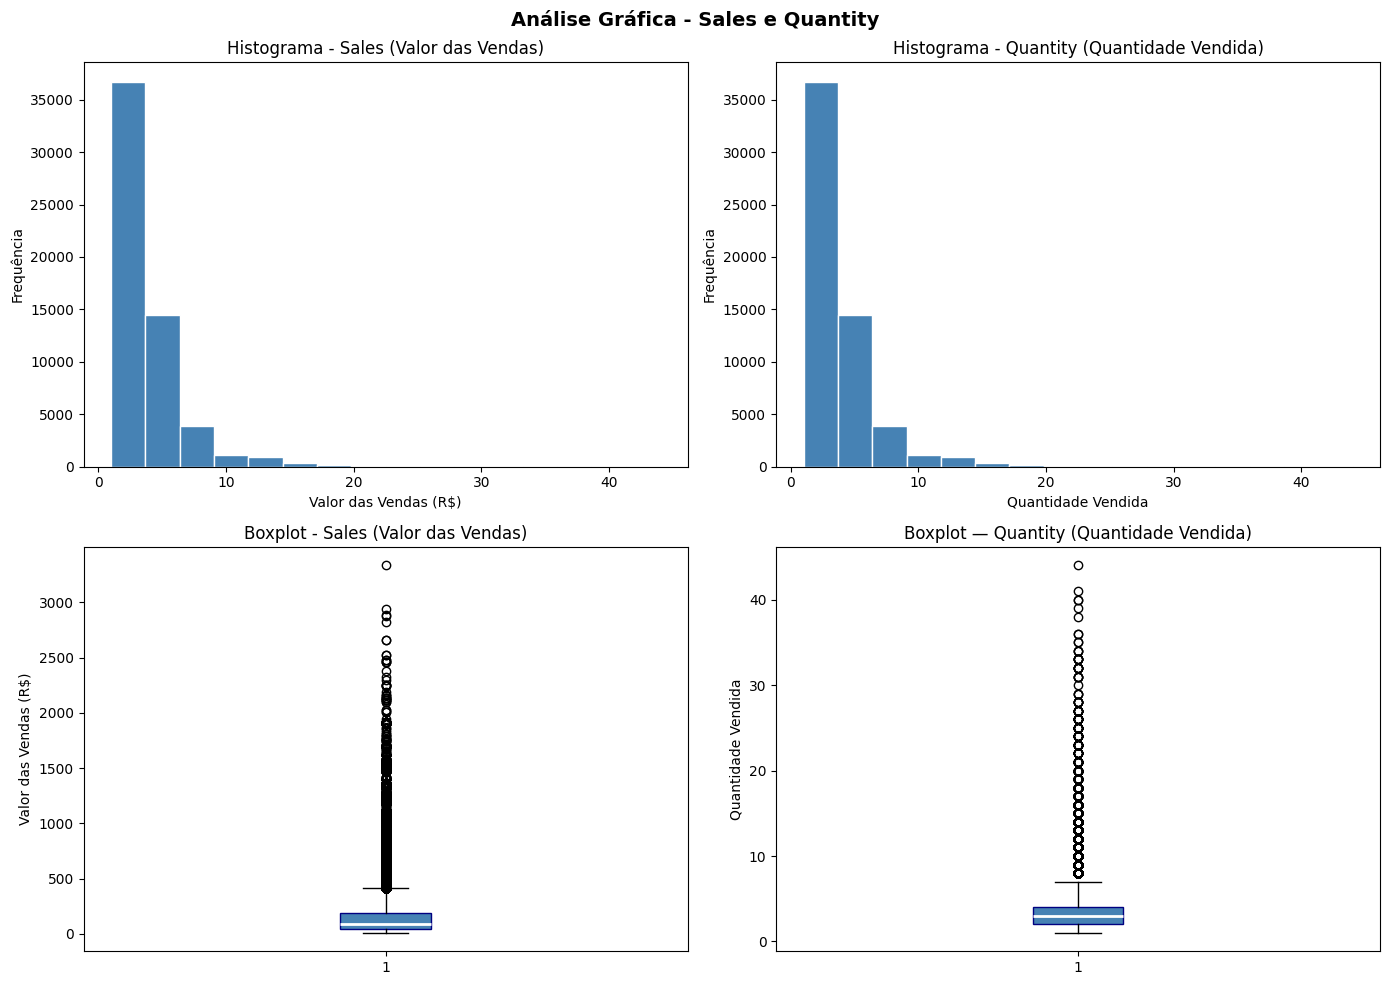


Gráficos gerados e salvos como "graficos_sales_quantity.png" com sucesso!


In [18]:
# configuração da figura com 4 subgráficos (2 para cada variável)
fig, eixos=plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise Gráfica - Sales e Quantity', fontsize=14, fontweight='bold')

# Histograma - Sales
eixos[0, 0].hist(df_sales['Quantity'], bins=k, color='steelblue', edgecolor='white')
eixos[0, 0].set_title('Histograma - Sales (Valor das Vendas)')
eixos[0, 0].set_xlabel('Valor das Vendas (R$)')
eixos[0, 0].set_ylabel('Frequência')

# Histograma - Quantity
eixos[0, 1].hist(df_sales['Quantity'], bins=k, color='steelblue', edgecolor='white')
eixos[0, 1].set_title('Histograma - Quantity (Quantidade Vendida)')
eixos[0, 1].set_xlabel('Quantidade Vendida')
eixos[0, 1].set_ylabel('Frequência')

# Boxplot - Sales
eixos[1, 0].boxplot(df_sales['Sales'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='white', linewidth=2))
eixos[1, 0].set_title('Boxplot - Sales (Valor das Vendas)')
eixos[1, 0].set_ylabel('Valor das Vendas (R$)')

# Boxplot - Quantity
eixos[1, 1].boxplot(df_sales["Quantity"], vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", color="navy"),
                    medianprops=dict(color="white", linewidth=2))
eixos[1, 1].set_title("Boxplot — Quantity (Quantidade Vendida)")
eixos[1, 1].set_ylabel("Quantidade Vendida")

# ajuste do espaçamento entre os gráficos
plt.tight_layout()

# salvamento e exibição dos gráficos
plt.savefig('graficos_sales_quantity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGráficos gerados e salvos como "graficos_sales_quantity.png" com sucesso!')

#### Histograma - Sales
##### A distribuição do valor das vendas é fortemente assimétrica à direita: a grande maioria das transações se concentra em valores baixos, enquanto poucos registros de alto valor se estendem pela cauda direita do gráicos. Isso é consistente com o que já observei na média e mediana da pergunta A.

#### Historograma - Quantity
##### A distribuição da quantidade vendida também apresenta assimetria à direita, porém de forma mais suave. A maior parte dos pedidos possui entre 1 e 5 unidades, com poucos pedidos de quantidade muito elevada.

#### Boxplot - Sales
##### A caixa central está bastante comprimida na parte inferior do gráfico, com uma longa cauda de pontos acima (outliers). Isso confirma que existem vendas de valor muito elevado que fogem do padrão da maioria dos registros.

#### Boxplot - Quantity
##### A caixa central é mais compacta e equilibrada em relação ao Sales, mas também apresneta outliers na parte superior, represnetando pedidos com quantidades muito acima do habitual